# RQ3: Post-Peak Decline Analysis

**Research question:** Do players in different positions decline at different rates after their peak?

We examine whether the post-peak decline in **market value** and **on-field output** is sharper for some positions than others.

**Inputs:** `player_lifecycle_backbone.parquet`

**Outputs:** `D_rq3_decline_summary.csv`, two presentation-ready figures, `D_rq3_profile.md`

## 1. Setup

In [1]:
import cProfile
import io
import pstats
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve project root whether running locally or on Colab
_candidates = [
    Path("/Users/fqxin/Desktop/1019_Py/football_lifecycle"),
    Path("/content/drive/MyDrive/football_lifecycle"),
    Path("../"),  # if notebook is inside notebooks/
]
PROJECT_ROOT = next(
    (p.resolve() for p in _candidates if (p / "data" / "processed").exists()), None
)
if PROJECT_ROOT is None:
    raise RuntimeError("Cannot find project root. Add your path to _candidates above.")

sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

INTERIM   = PROJECT_ROOT / "data" / "interim"
PROCESSED = PROJECT_ROOT / "data" / "processed"
OUT_TABLES   = PROJECT_ROOT / "outputs" / "tables"
OUT_FIGURES  = PROJECT_ROOT / "outputs" / "figures"
OUT_PROFILING = PROJECT_ROOT / "outputs" / "profiling"

for d in [OUT_TABLES, OUT_FIGURES, OUT_PROFILING]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 11})

Project root: /Users/fqxin/Desktop/1019_Py/football_lifecycle


In [2]:
from src.d_rq3_decline_utils import (
    POSITION_ORDER,
    POSITION_PALETTE,
    extract_peak_per_player,
    extract_post_peak_data,
    compute_all_decline_metrics,
    compute_decline_slopes_base,
    compute_decline_slopes_vectorized,
    plot_decline_boxplot,
    plot_mean_trajectory,
    summarize_decline_by_position
)

## 2. Load Data

In [3]:
backbone = pd.read_parquet(PROCESSED / "player_lifecycle_backbone.parquet")
backbone.head()

,player_id,market_value_date,market_value_eur,player_name,date_of_birth,raw_position,raw_sub_position,broad_position,age_days,age_years,n_market_value_obs,market_value_rank_desc,is_peak_value_obs
0,10,2004-10-03,7000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9613.0,26.318960,23,9,False
1,10,2005-01-06,9000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9708.0,26.579055,23,7,False
2,10,2005-05-04,12000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9826.0,26.902122,23,6,False
3,10,2005-09-29,15000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,9974.0,27.307324,23,5,False
4,10,2006-01-08,20000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,10075.0,27.583847,23,3,False


In [4]:
print("Backbone shape:", backbone.shape)
print("Backbone columns:", backbone.columns.tolist())

print("\nBroad position counts:")
print(backbone["broad_position"].value_counts())

print("\nRows with is_peak_value_obs:", backbone["is_peak_value_obs"].sum())
print("Players in backbone:       ", backbone["player_id"].nunique())

Backbone shape: (836635, 13)
Backbone columns: ['player_id', 'market_value_date', 'market_value_eur', 'player_name', 'date_of_birth', 'raw_position', 'raw_sub_position', 'broad_position', 'age_days', 'age_years', 'n_market_value_obs', 'market_value_rank_desc', 'is_peak_value_obs']

Broad position counts:
broad_position
Defender      275452
Midfielder    246939
Forward       227838
Goalkeeper     86406
Other              0
Name: count, dtype: int64

Rows with is_peak_value_obs: 121262
Players in backbone:        58944


In [5]:
# Check if any players have multiple broad positions in the backbone.
position_consistency = (
    backbone.groupby("player_id")["broad_position"]
    .nunique()
)

n_inconsistent = (position_consistency > 1).sum()
total = position_consistency.shape[0]

print(f"Players with >1 broad position: {n_inconsistent} / {total} ({n_inconsistent/total:.1%})")

Players with >1 broad position: 0 / 58944 (0.0%)


## 3. Extract Peak Age Per Player

For each player, return the earliest observation where market value reaches
its maximum. 
* Using the precomputed is_peak_value_obs flag — consistent with
B's compute_peak_age_optimized. 
* Sorting by market_value_date before
groupby.first() ensures tied-peak players contribute their earliest peak date.

In [6]:
peak_per_player = extract_peak_per_player(backbone)
peak_per_player.head()

,player_id,peak_age,peak_value,broad_position
0,10,28.095825,30000000.0,Forward
1,100001,30.595483,3500000.0,Forward
2,100011,27.808350,550000.0,Defender
3,100012,20.254620,150000.0,Forward
4,1000135,19.770021,100000.0,Forward


In [7]:
print("Players with a peak observation:", len(peak_per_player))
print("\nPeak age summary:")
print(peak_per_player["peak_age"].describe().round(2))

Players with a peak observation: 58944

Peak age summary:
count    58944.00
mean        24.28
std          3.76
min         15.72
25%         21.31
50%         23.99
75%         26.98
max         41.30
Name: peak_age, dtype: float64


In [8]:
peak_age_by_pos = (
    peak_per_player[peak_per_player["broad_position"].isin(POSITION_ORDER)]
    .groupby("broad_position", observed=True)["peak_age"]
    .agg(["count", "median", "mean", "std"])
    .round(2)
    .loc[POSITION_ORDER]
)
print("Peak age by position:")
display(peak_age_by_pos)

Peak age by position:


,count,median,mean,std
broad_position,,,,
Goalkeeper,6243,24.14,24.59,4.47
Defender,19258,24.23,24.45,3.64
Midfielder,17485,23.82,24.13,3.69
Forward,15958,23.86,24.12,3.66


## 4. Extract Post-Peak Observations

* Post-peak = all backbone rows where `age_years > peak_age` for that player.  
* Players whose peak occurs at their final observation have no post-peak data and are excluded. 
* Three new parameters:
    * `age_since_peak` = `age_years` - `peak_age`
    * `log_value` =  log(`market_value_eur`)
    * `value_ratio` =  `market_value_eur` / `peak_value`

In [9]:
df = backbone.merge(
        peak_per_player[["player_id", "peak_age", "peak_value"]],
        on="player_id",
        how="inner",
    )
post = df[df["age_years"] > df["peak_age"]].copy()
post["age_since_peak"] = post["age_years"] - post["peak_age"]
post["log_value"] = np.log(post["market_value_eur"])
post["value_ratio"] = post["market_value_eur"] / post["peak_value"]

In [10]:
post_peak = extract_post_peak_data(backbone, peak_per_player)
post_peak.head()

,player_id,market_value_date,market_value_eur,player_name,date_of_birth,raw_position,raw_sub_position,broad_position,age_days,age_years,n_market_value_obs,market_value_rank_desc,is_peak_value_obs,peak_age,peak_value,age_since_peak,log_value,value_ratio
0,10,2007-06-20,23000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,10603.0,29.029432,23,2,False,28.095825,30000000.0,0.933607,16.951005,0.766667
1,10,2008-06-03,20000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,10952.0,29.984942,23,3,False,28.095825,30000000.0,1.889117,16.811243,0.666667
2,10,2009-06-09,18000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,11323.0,31.000684,23,4,False,28.095825,30000000.0,2.904860,16.705882,0.600000
3,10,2009-08-29,12000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,11404.0,31.222450,23,6,False,28.095825,30000000.0,3.126626,16.300417,0.400000
4,10,2010-01-16,9000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,11544.0,31.605749,23,7,False,28.095825,30000000.0,3.509925,16.012735,0.300000


In [11]:
print("Post-peak rows:   ", len(post_peak))
print("Players covered:  ", post_peak["player_id"].nunique())
print("\nPost-peak obs counts per player:")
print(post_peak.groupby("player_id").size().describe().round(1))

Post-peak rows:    431652
Players covered:   53363

Post-peak obs counts per player:
count    53363.0
mean         8.1
std          6.6
min          1.0
25%          3.0
50%          6.0
75%         12.0
max         44.0
dtype: float64


In [12]:
# filter out players have >=3 post-peak observations (minimum for slope fit)
n_post = post_peak.groupby("player_id").size()
for threshold in [1, 2, 3, 5]:
    n = (n_post >= threshold).sum()
    print(f"Players with >= {threshold} post-peak obs: {n:,} ({100*n/len(peak_per_player):.1f}% of all peak players)")

eligible = n_post[n_post >= 3].index
post_peak_filtered = post_peak[post_peak["player_id"].isin(eligible)].copy()
print("\nPost-peak filtered shape:", post_peak_filtered.shape)
post_peak_filtered.head()

Players with >= 1 post-peak obs: 53,363 (90.5% of all peak players)
Players with >= 2 post-peak obs: 48,428 (82.2% of all peak players)
Players with >= 3 post-peak obs: 41,513 (70.4% of all peak players)
Players with >= 5 post-peak obs: 32,028 (54.3% of all peak players)

Post-peak filtered shape: (412887, 18)


,player_id,market_value_date,market_value_eur,player_name,date_of_birth,raw_position,raw_sub_position,broad_position,age_days,age_years,n_market_value_obs,market_value_rank_desc,is_peak_value_obs,peak_age,peak_value,age_since_peak,log_value,value_ratio
0,10,2007-06-20,23000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,10603.0,29.029432,23,2,False,28.095825,30000000.0,0.933607,16.951005,0.766667
1,10,2008-06-03,20000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,10952.0,29.984942,23,3,False,28.095825,30000000.0,1.889117,16.811243,0.666667
2,10,2009-06-09,18000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,11323.0,31.000684,23,4,False,28.095825,30000000.0,2.904860,16.705882,0.600000
3,10,2009-08-29,12000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,11404.0,31.222450,23,6,False,28.095825,30000000.0,3.126626,16.300417,0.400000
4,10,2010-01-16,9000000.0,Miroslav Klose (10),1978-06-09,Attack,<NA>,Forward,11544.0,31.605749,23,7,False,28.095825,30000000.0,3.509925,16.012735,0.300000


## 5. Compute Decline Slopes

### Decline metric: log-linear slope

For each player we fit OLS: $\log(\text{market\_value}) = \alpha + \beta \cdot \text{age\_since\_peak} + \varepsilon$

- $\beta < 0$ → value falls after peak (expected for most players)
- We use the log scale so the slope is interpretable as an **approximate % change per year**: $(e^\beta - 1) \times 100$
- Minimum 3 post-peak observations required to fit a meaningful slope

In [13]:
slopes = compute_decline_slopes_vectorized(post_peak_filtered)

last_obs = (
    post_peak_filtered
    .sort_values("age_years")
    .groupby("player_id", as_index=False)
    .last()[["player_id", "value_ratio", "age_years"]]
    .rename(columns={"value_ratio": "final_value_ratio", "age_years": "last_obs_age"})
)

decline_df = (
    peak_per_player
    .merge(slopes, on="player_id", how="inner")
    .merge(last_obs, on="player_id", how="left")
    .dropna(subset=["decline_slope"])
)
decline_df["decline_pct_per_year"] = (np.exp(decline_df["decline_slope"]) - 1) * 100
decline_df["broad_position"] = decline_df["broad_position"].astype("category")
decline_df.head()

,player_id,peak_age,peak_value,broad_position,decline_slope,n_post_peak_obs,final_value_ratio,last_obs_age,decline_pct_per_year
0,10,28.095825,30000000.0,Forward,-0.431724,17,0.033333,37.568789,-35.061138
1,100001,30.595483,3500000.0,Forward,-0.902052,9,0.057143,34.212183,-59.426363
2,100011,27.808350,550000.0,Defender,-0.316749,4,0.181818,34.395619,-27.148671
3,100012,20.254620,150000.0,Forward,-0.068722,10,0.500000,26.173854,-6.641420
4,1000135,19.770021,100000.0,Forward,0.000000,3,1.000000,21.284052,0.000000


In [14]:
# peak_per_player, post_peak_filtered, decline_df = compute_all_decline_metrics(
#     backbone,
#     min_post_peak_obs=3,
# )
# decline_df.head()

In [15]:
print("Players in decline_df (slope estimated):", len(decline_df))
print("\nDecline % per year — overall summary:")
print(decline_df["decline_pct_per_year"].describe().round(2))

Players in decline_df (slope estimated): 41513

Decline % per year — overall summary:
count    41513.00
mean       -20.36
std         21.08
min        -98.28
25%        -31.50
50%        -19.65
75%         -8.47
max       1053.14
Name: decline_pct_per_year, dtype: float64


In [16]:
# Sanity check: nearly all players should have negative slopes (value falls after peak)
n_declining = (decline_df["decline_slope"] < 0).sum()
n_total = len(decline_df)
print(f"Players with negative slope (declining): {n_declining:,} / {n_total:,} ({100*n_declining/n_total:.1f}%)")
print("\nMedian decline rate by position:")
print(
    decline_df[decline_df["broad_position"].isin(POSITION_ORDER)]
    .groupby("broad_position", observed=True)["decline_pct_per_year"]
    .median()
    .round(2)
    .loc[POSITION_ORDER]
)

Players with negative slope (declining): 36,568 / 41,513 (88.1%)

Median decline rate by position:
broad_position
Goalkeeper   -16.73
Defender     -19.22
Midfielder   -19.81
Forward      -20.93
Name: decline_pct_per_year, dtype: float64


## 6. Position-Level Summary Statistics

In [17]:
summary = summarize_decline_by_position(decline_df)
display(summary.round(3))

,broad_position,n_players,median_peak_age,mean_peak_age,median_decline_pct_yr,mean_decline_pct_yr,q25_decline,q75_decline,median_final_value_ratio
0,Goalkeeper,4451,24.630,24.886,-16.729,-17.880,-28.800,-4.030,0.400
1,Defender,13530,24.643,24.735,-19.224,-20.041,-30.981,-8.431,0.333
2,Midfielder,12218,24.170,24.352,-19.814,-20.445,-31.617,-8.543,0.333
3,Forward,11314,24.194,24.322,-20.932,-21.638,-32.798,-9.818,0.312


## 7. Figure 1 — Post-Peak Decline Rate by Position (Box Plot)

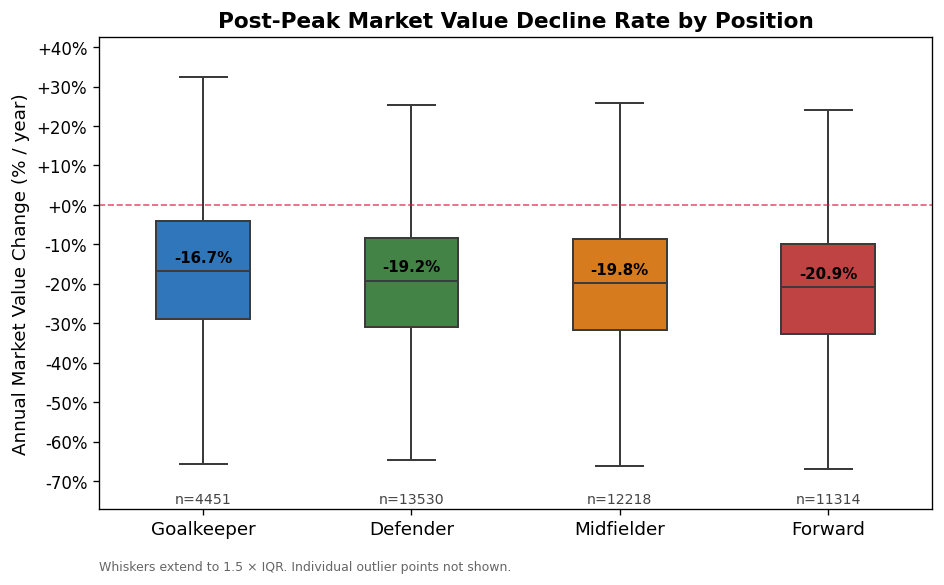

Saved Figure 1.


In [18]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
plot_decline_boxplot(decline_df, ax=ax1)

# Annotate with median labels
for i, pos in enumerate(POSITION_ORDER):
    med = decline_df.loc[decline_df["broad_position"] == pos, "decline_pct_per_year"].median()
    ax1.text(i, med + 1.5, f"{med:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

fig1.tight_layout()
fig1.savefig(OUT_FIGURES / "D_rq3_fig1_decline_boxplot.png", bbox_inches="tight")
plt.show()
print("Saved Figure 1.")

## 8. Figure 2 — Average Post-Peak Market Value Trajectory by Position

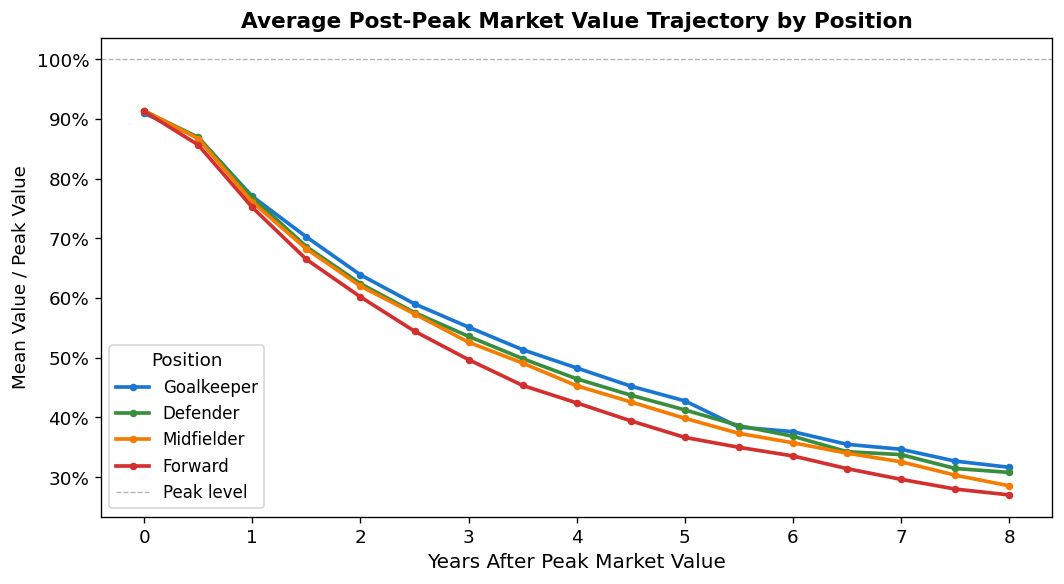

Saved Figure 2.


In [19]:
fig2, ax2 = plt.subplots(figsize=(9, 5))
plot_mean_trajectory(post_peak_filtered, ax=ax2, max_years_since_peak=8.0)

fig2.tight_layout()
fig2.savefig(OUT_FIGURES / "D_rq3_fig2_mean_trajectory.png", bbox_inches="tight")
plt.show()
print("Saved Figure 2.")

## 9. Profiling — Vectorized vs Apply-Based Slope Estimation

The core decline computation loops conceptually over ~30K players.  
We compare two implementations:
- **Baseline**: `groupby.apply` with `scipy.stats.linregress` (Python-level loop)
- **Optimized**: vectorized groupby aggregations using the closed-form OLS formula

In [20]:
# Baseline
t0 = time.perf_counter()
_ = compute_decline_slopes_base(post_peak_filtered)
t_apply = time.perf_counter() - t0
print(f"Baseline (apply + linregress): {t_apply:.2f}s")

Baseline (apply + linregress): 2.28s


In [21]:
# Optimized: vectorized
t0 = time.perf_counter()
_ = compute_decline_slopes_vectorized(post_peak_filtered)
t_vec = time.perf_counter() - t0
print(f"Optimized (vectorized groupby): {t_vec:.2f}s")
print(f"Speedup: {t_apply / t_vec:.1f}x")

Optimized (vectorized groupby): 0.05s
Speedup: 47.8x


In [22]:
# Full pipeline profiling with cProfile
profiler = cProfile.Profile()
t0 = time.perf_counter()
profiler.enable()

_ = compute_all_decline_metrics(backbone, min_post_peak_obs=3)

profiler.disable()
elapsed = time.perf_counter() - t0

buf = io.StringIO()
pstats.Stats(profiler, stream=buf).sort_stats("cumtime").print_stats(20)
profile_output = buf.getvalue()

print(f"Full RQ3 pipeline runtime: {elapsed:.2f}s")
print(profile_output[:3000])

Full RQ3 pipeline runtime: 0.46s
         40269 function calls (39479 primitive calls) in 0.454 seconds

   Ordered by: cumulative time
   List reduced from 1050 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.458    0.229 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    0.458    0.229 {built-in method builtins.exec}
        1    0.022    0.022    0.454    0.454 /Users/fqxin/Desktop/1019_Py/football_lifecycle/src/d_rq3_decline_utils.py:120(compute_all_decline_metrics)
        6    0.000    0.000    0.139    0.023 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/pandas/core/groupby/groupby.py:1898(_agg_general)
        6    0.000    0.000    0.139    0.023 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/pandas/core/groupby/groupby.py:1964(_cython_agg_general)
       27    0.000

## 13. Save Outputs

In [23]:
# Main results table
summary_path = OUT_TABLES / "D_rq3_decline_summary.csv"
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

Saved: /Users/fqxin/Desktop/1019_Py/football_lifecycle/outputs/tables/D_rq3_decline_summary.csv


In [24]:
profile_md = f"""# D RQ3 Profiling Note

## Pipeline
RQ3 decline slope computation over backbone ({len(backbone):,} rows, {backbone['player_id'].nunique():,} players).

## Runtime
Full pipeline: {elapsed:.2f}s

## Bottleneck identified
The per-player slope estimation is the core computation.  
**Baseline** (`groupby.apply` + `scipy.stats.linregress`): {t_apply:.2f}s  
**Optimized** (vectorized closed-form OLS via groupby aggregations): {t_vec:.2f}s  
**Speedup: {t_apply / t_vec:.1f}x**

## Optimization strategy
Replaced Python-level iteration (groupby.apply calling linregress per player) with
a single pass of vectorized pandas aggregations using the closed-form OLS formula:

    slope = (n * Σxy - Σx * Σy) / (n * Σx² - (Σx)²)

Pre-computing `x_sq` and `xy` as new columns before groupby avoids repeated
element-wise operations inside the apply loop. All computation stays in
numpy/pandas vectorized paths.

## cProfile top functions
```
{profile_output[:1500]}
```
"""

profile_path = OUT_PROFILING / "D_rq3_profile.md"
profile_path.write_text(profile_md, encoding="utf-8")
print("Saved:", profile_path)

Saved: /Users/fqxin/Desktop/1019_Py/football_lifecycle/outputs/profiling/D_rq3_profile.md


In [25]:
# Verify all outputs exist
outputs = [
    OUT_FIGURES / "D_rq3_fig1_decline_boxplot.png",
    OUT_FIGURES / "D_rq3_fig2_mean_trajectory.png",
    OUT_TABLES  / "D_rq3_decline_summary.csv",
    OUT_PROFILING / "D_rq3_profile.md",
]
for p in outputs:
    print(p.name, "exists:", p.exists())

D_rq3_fig1_decline_boxplot.png exists: True
D_rq3_fig2_mean_trajectory.png exists: True
D_rq3_decline_summary.csv exists: True
D_rq3_profile.md exists: True
